In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [15]:
air = pd.read_csv("Air Quality.csv")

heart = pd.read_csv("heart.csv")

In [16]:
print(air.head())

print(heart.head())

  Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,
0  10/03/2004,18:00:00,2.6,1360,150,11.9,1046,166...                                                                          
1  10/03/2004,19:00:00,2,1292,112,9.4,955,103,117...                                                                          
2  10/03/2004,20:00:00,2.2,1402,88,9.0,939,131,11...                                                                          
3  10/03/2004,21:00:00,2.2,1376,80,9.2,948,172,10...                                                                          
4  10/03/2004,22:00:00,1.6,1272,51,6.5,836,131,12...                                                                          
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      

In [17]:
print(air.info())

print(heart.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 1 columns):
 #   Column                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                        --------------  ----- 
 0   Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,  9471 non-null   object
dtypes: object(1)
memory usage: 74.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   f

In [18]:
air = air.ffill()

heart = heart.fillna(heart.mean(numeric_only=True))

In [19]:
air = air.drop_duplicates()

heart = heart.drop_duplicates()

In [20]:
air['source'] = 'air'

heart['source'] = 'heart'

In [21]:
data = pd.concat([air, heart], ignore_index=True, sort=False)

In [22]:
print(air.head())

print(heart.head())

  Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,  \
0  10/03/2004,18:00:00,2.6,1360,150,11.9,1046,166...                                                                             
1  10/03/2004,19:00:00,2,1292,112,9.4,955,103,117...                                                                             
2  10/03/2004,20:00:00,2.2,1402,88,9.0,939,131,11...                                                                             
3  10/03/2004,21:00:00,2.2,1376,80,9.2,948,172,10...                                                                             
4  10/03/2004,22:00:00,1.6,1272,51,6.5,836,131,12...                                                                             

  source  
0    air  
1    air  
2    air  
3    air  
4    air  
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0  

In [23]:
data = pd.get_dummies(data, drop_first=True)

In [24]:
print(air.head())

print(heart.head())

  Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,  \
0  10/03/2004,18:00:00,2.6,1360,150,11.9,1046,166...                                                                             
1  10/03/2004,19:00:00,2,1292,112,9.4,955,103,117...                                                                             
2  10/03/2004,20:00:00,2.2,1402,88,9.0,939,131,11...                                                                             
3  10/03/2004,21:00:00,2.2,1376,80,9.2,948,172,10...                                                                             
4  10/03/2004,22:00:00,1.6,1272,51,6.5,836,131,12...                                                                             

  source  
0    air  
1    air  
2    air  
3    air  
4    air  
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0  

In [25]:
data.columns = data.columns.str.replace(' ', '_')

In [26]:
for col in data.select_dtypes(include=np.number).columns:
    
    data = data[
        (data[col] >= data[col].quantile(0.01)) &
        (data[col] <= data[col].quantile(0.99))
    ]

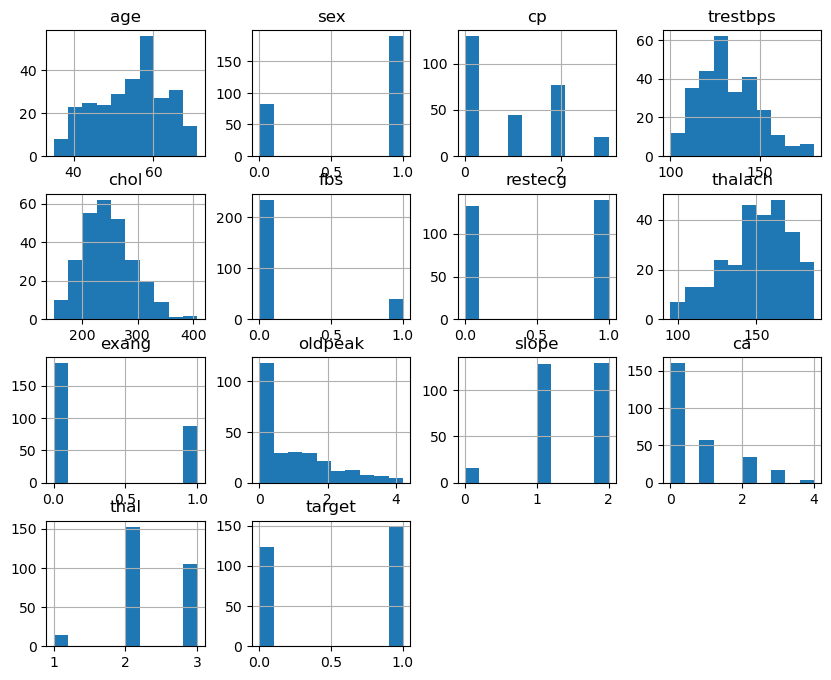

In [27]:
data.hist(figsize=(10,8))

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(data.corr(), cmap='coolwarm')

plt.show()

In [ ]:
heart = heart.select_dtypes(include=np.number)

In [ ]:
X = heart.drop('target', axis=1)

y = heart['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.2
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)

print("Model Accuracy:", acc)